In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter

from config import no_outlier_check, remote_features, insitu_features1
from preparation import load_and_prepare_data, handle_duplicate_values, handle_outliers, reindex_daily, handle_missing_values, calculate_stats_from_random_points, smooth_data, merge_datasets, slice_by_dates

In [24]:
remote_df = load_and_prepare_data('../data/processed/satellites/SDH2_S2_20m_2023-10_2026-06.csv')
remote_df = handle_duplicate_values(remote_df)
remote_df = reindex_daily(remote_df)
remote_df = handle_outliers(remote_df, 3.0)
remote_df = handle_missing_values(remote_df, 'time')
remote_df = calculate_stats_from_random_points(remote_df, 10)
remote_df = smooth_data(remote_df, None, 7, 2)

In [25]:
insitu_df = load_and_prepare_data('../data/processed/in-situ/SDH1_daily-insitu-data.csv')
insitu_df = handle_duplicate_values(insitu_df)
insitu_df = reindex_daily(insitu_df)
insitu_df = handle_outliers(insitu_df, 3.0, no_outlier_check)
insitu_df = handle_missing_values(insitu_df, 'time')

In [ ]:
features = insitu_features1 + remote_features

fused_df = merge_datasets(insitu_df, remote_df)
fused_df = fused_df[features]
fused_df = slice_by_dates(fused_df, '2024-05-22', '2026-01-24')

In [27]:
z_df = fused_df.apply(zscore, nan_policy='omit')

In [28]:
z_df

,SDH1PS01_gw-depth_m,ATMOS41_precipitation_mm,ndvi_mean,ndwi_mean,mndwi_mean,ndmi_mean,ndmi2_mean,str_mean,brightness_mean,greenness_mean,wetness_mean
Timestamps,,,,,,,,,,,
2024-05-22,-0.798280,NaN,-0.491872,0.595618,0.599307,0.179944,-0.134957,-0.131437,0.029643,-0.182080,0.369336
2024-05-23,-0.798280,NaN,-0.475730,0.579890,0.638352,0.228947,-0.095040,-0.099376,0.013929,-0.165273,0.411252
2024-05-24,-0.821934,NaN,-0.447847,0.552198,0.721917,0.329809,0.012492,-0.072045,0.031463,-0.154589,0.498476
2024-05-25,-0.869243,NaN,-0.405899,0.509016,0.835090,0.470256,0.168093,-0.041479,0.064351,-0.140993,0.618218
2024-05-26,-0.940206,NaN,-0.380157,0.484085,0.922401,0.572935,0.279765,-0.017735,0.088061,-0.134317,0.708064
...,...,...,...,...,...,...,...,...,...,...,...
2026-01-20,-0.522312,0.662856,2.154888,-2.171461,-1.363478,0.187922,1.190329,1.803530,-1.959043,1.858928,0.511706
2026-01-21,-0.396156,4.966917,2.185538,-2.187721,-1.307688,0.253631,1.197556,1.941275,-2.001287,1.876471,0.548997
2026-01-22,-0.064995,9.552674,2.216188,-2.203981,-1.251899,0.319340,1.204783,2.079021,-2.043531,1.894013,0.586288


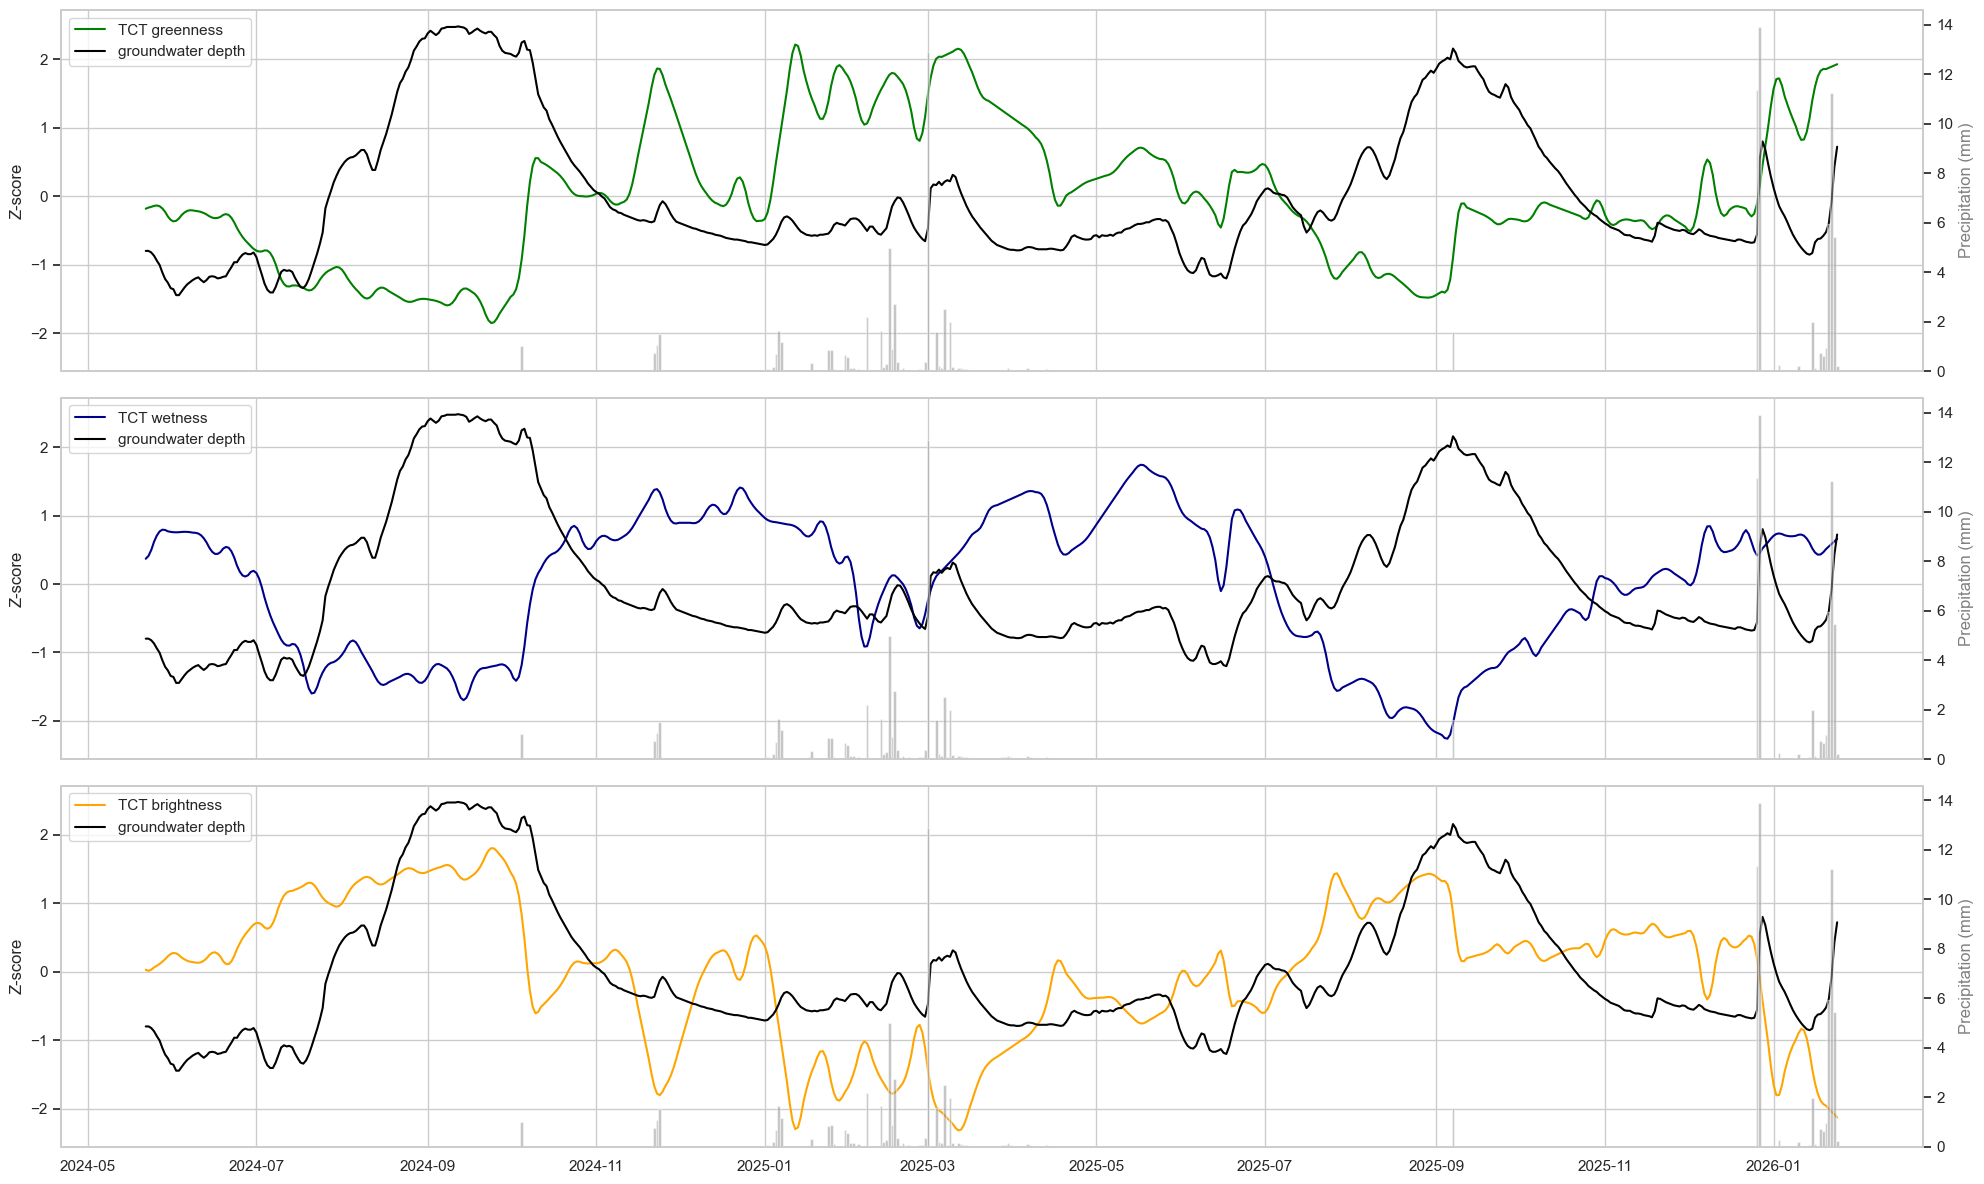

In [29]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20,12), sharex=True, sharey=True)

ax1.plot(z_df.index, z_df['greenness_mean'], label='TCT greenness', c='green', alpha=1)
ax1.plot(z_df.index, z_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax1.set_ylabel('Z-score')
ax1.legend(loc='upper left')

ax2.plot(z_df.index, z_df['wetness_mean'], label='TCT wetness', c='darkblue', alpha=1)
ax2.plot(z_df.index, z_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax2.set_ylabel('Z-score')
ax2.legend(loc='upper left')

ax3.plot(z_df.index, z_df['brightness_mean'], label='TCT brightness', c='orange', alpha=1)
ax3.plot(z_df.index, z_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax3.set_ylabel('Z-score')
ax3.legend(loc='upper left')

ax4 = ax1.twinx()
ax4.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax4.set_ylabel('Precipitation (mm)', color='gray')
ax4.grid(False)

ax5 = ax2.twinx()
ax5.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax5.set_ylabel('Precipitation (mm)', color='gray')
ax5.grid(False)

ax6 = ax3.twinx()
ax6.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax6.set_ylabel('Precipitation (mm)', color='gray')
ax6.grid(False)

plt.grid(False)
plt.tight_layout()
plt.show()

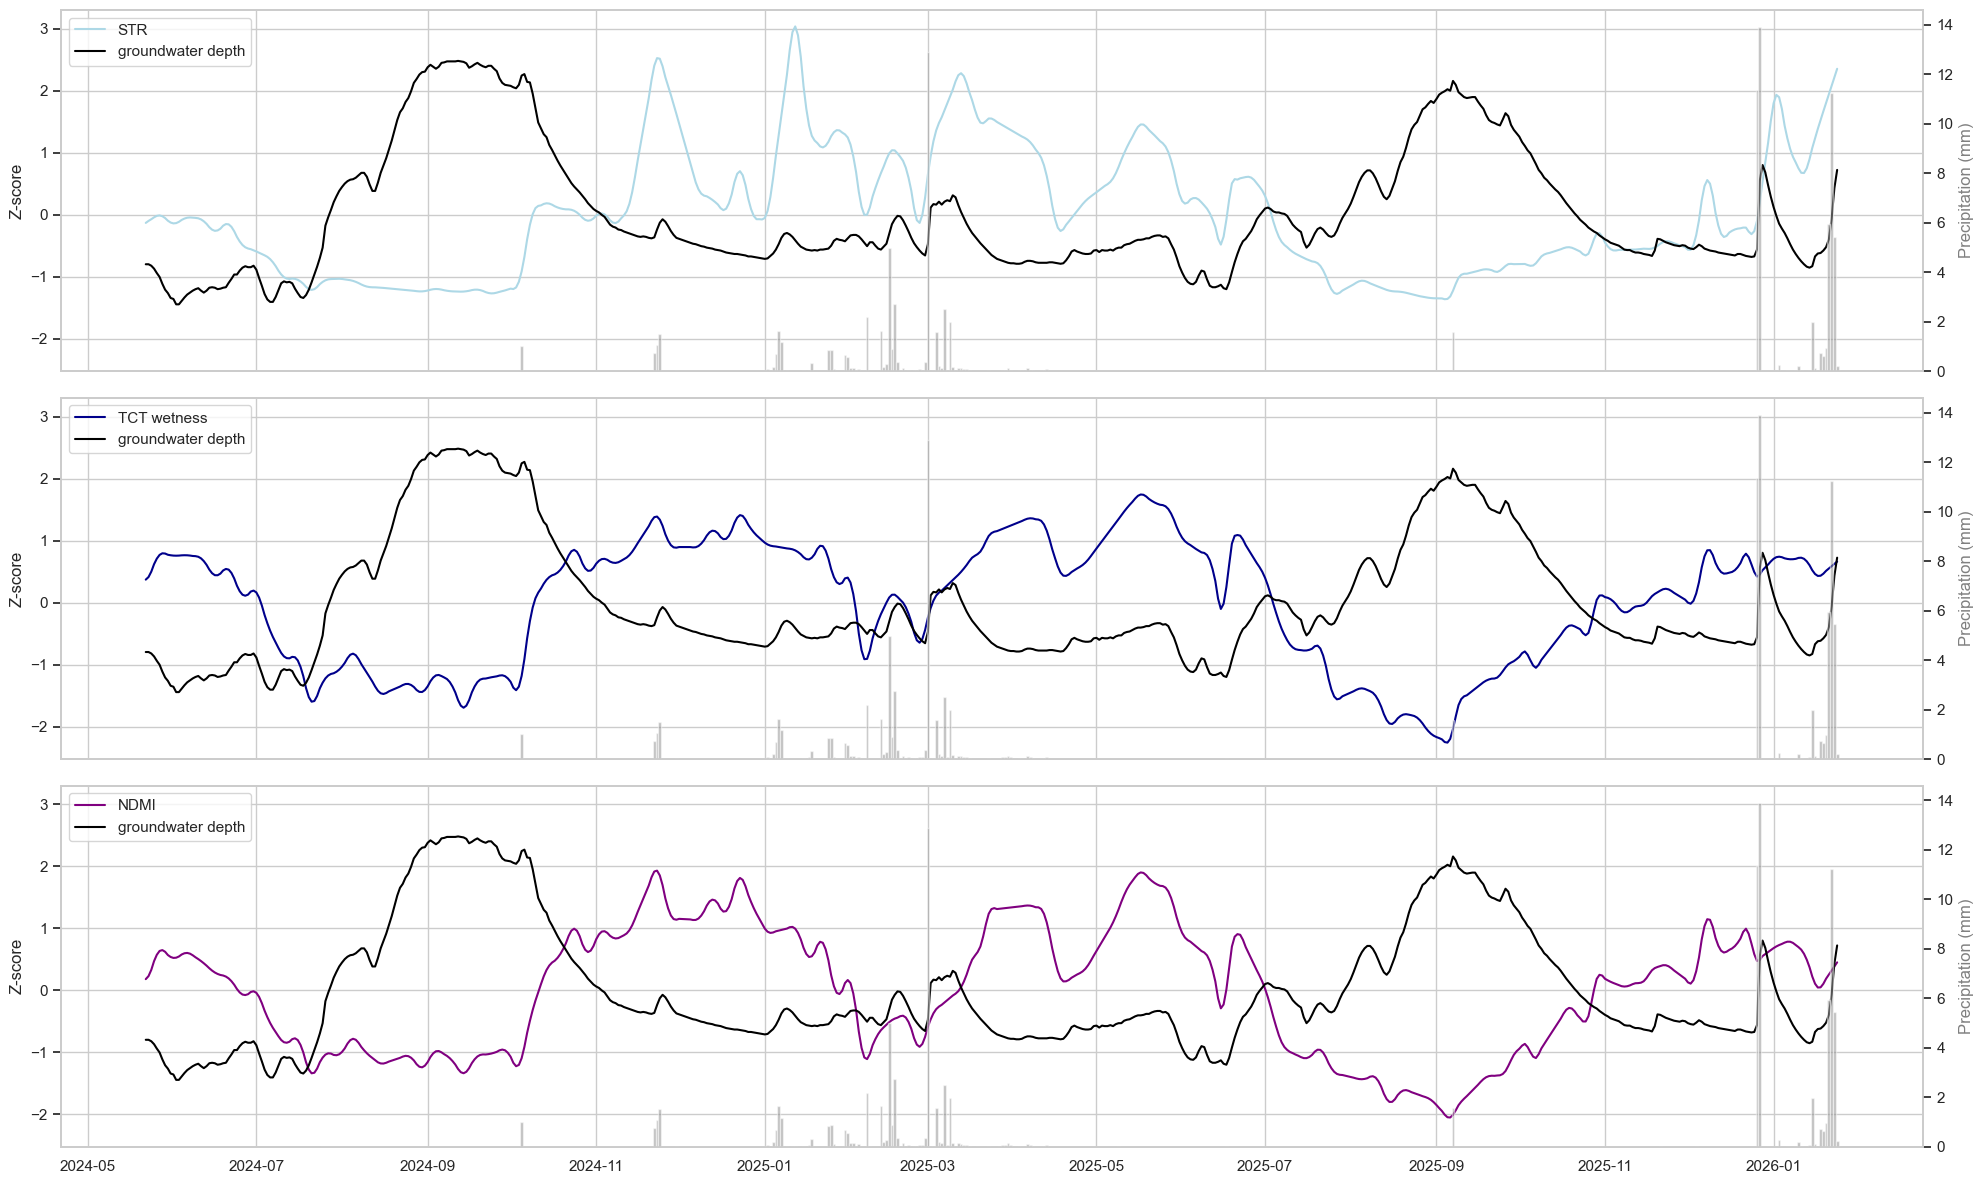

In [30]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20,12), sharex=True, sharey=True)

ax1.plot(z_df.index, z_df['str_mean'], label='STR', c='lightblue', alpha=1)
ax1.plot(z_df.index, z_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax1.set_ylabel('Z-score')
ax1.legend(loc='upper left')

ax2.plot(z_df.index, z_df['wetness_mean'], label='TCT wetness', c='darkblue', alpha=1)
ax2.plot(z_df.index, z_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax2.set_ylabel('Z-score')
ax2.legend(loc='upper left')

ax3.plot(z_df.index, z_df['ndmi_mean'], label='NDMI', c='purple', alpha=1)
ax3.plot(z_df.index, z_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax3.set_ylabel('Z-score')
ax3.legend(loc='upper left')

ax4 = ax1.twinx()
ax4.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax4.set_ylabel('Precipitation (mm)', color='gray')
ax4.grid(False)

ax5 = ax2.twinx()
ax5.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax5.set_ylabel('Precipitation (mm)', color='gray')
ax5.grid(False)

ax6 = ax3.twinx()
ax6.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax6.set_ylabel('Precipitation (mm)', color='gray')
ax6.grid(False)

plt.grid(False)
plt.tight_layout()
plt.show()

In [31]:
def wide_to_long(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Transforms a dataframe from wide to long format, keeping the index as the identifier.
    """
    # Reset the index to temporal column to use it in melt
    df_reset = dataframe.reset_index()
    # Get the name of the index column
    index_name = df_reset.columns[0]

    # Melt the dataframe from wide to long format
    long_df = pd.melt(
        df_reset,
        id_vars=[index_name],
        var_name="feature",
        value_name='value',
    )
    return long_df

long_df = wide_to_long(fused_df)
long_df_z = wide_to_long(z_df)

In [32]:
def plot_mean_with_std(stats_df: pd.DataFrame, feature: str, nStd: int=1):
    """
    Plot the mean feature value over time with a shaded area representing +/- one standard deviation.
    """
    # Set a clean seaborn style for scientific plots
    sns.set_theme(style="whitegrid")
    
    # Initialize the matplotlib figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define the time axis (dataframe index) and the statistical series
    time_axis = stats_df.index
    mean = stats_df[f'{feature}_mean']
    std = stats_df[f'{feature}_std']
    
    # Calculate the upper and lower bounds for the standard deviation
    lower_bound = mean - (nStd*std)
    upper_bound = mean + (nStd*std)
    
    # Plot the mean line using seaborn
    sns.lineplot(
        x=time_axis, 
        y=mean, 
        label=f'mean {feature}', 
        color='gray',
        linewidth=1.3, 
        ax=ax
    )
    
    # Fill the area between lower and upper bounds using matplotlib
    ax.fill_between(
        time_axis, 
        lower_bound, 
        upper_bound, 
        color='gray',
        alpha=0.3,
        label='±1 std dev'
    )
    
    ax.set_ylabel(f'{feature} value')
    ax.set_xlabel('')
    ax.legend(loc='upper left', frameon=True)
    plt.tight_layout()
    
    plt.show()

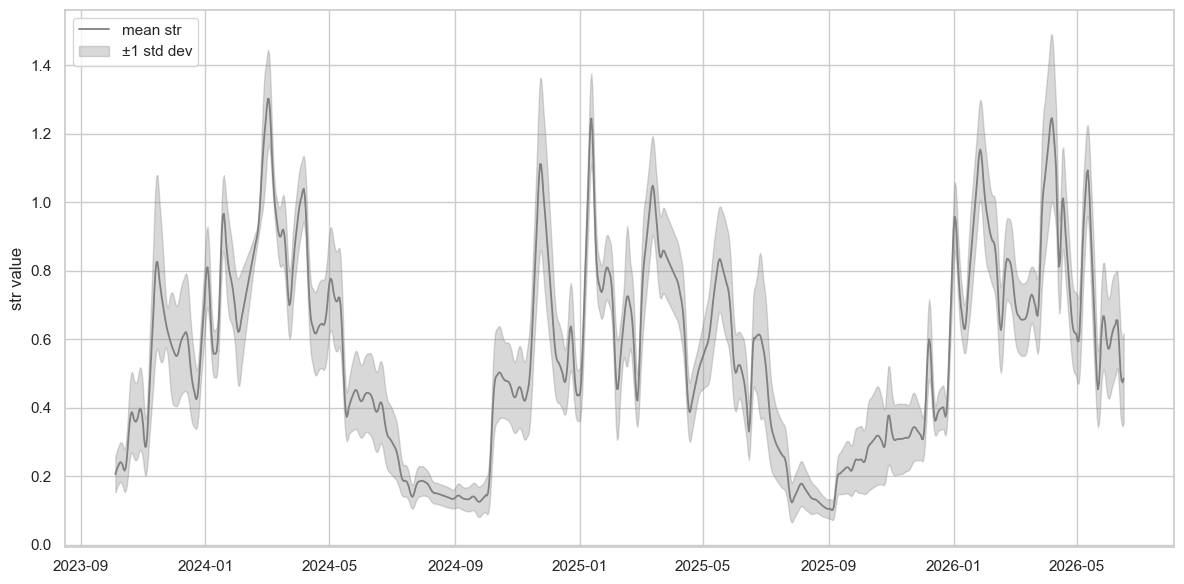

In [33]:
plot_mean_with_std(remote_df, 'str', 1)